#O que realmente determina a satisfação do cliente?

Ao explorar o dataset da Olist, um número chamou a atenção: 11 mil pedidos receberam nota 1, é a segunda avaliação mais comum dentro desse dataset, atrás apenas da nota 5.


As opiniões se concentram nos extremos. A hipótese óbvia é que a demora na entrega irrita o cliente. Investiguei com SQL - e os dados apontaram para algo mais específico: a quebra da expectativa de entrega do produto derruba a nota mais que qualquer espera.

##SETUP DO AMBIENTE PARA ANÁLISE DE DADOS
---
Dataset Olist (Kaggle): 9 tabelas CSV carregadas do Google Drive para um banco SQLite via pandas, consultadas com SQL.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import sqlite3
import os


# caminho da pasta do drive
caminho = '/content/drive/MyDrive/projetos_sql/olist/'

conn = sqlite3.connect('olist.db')

# carregando CSVs e jogando como tabelas

tabelas = {
    'orders': 'olist_orders_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'items': 'olist_order_items_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers':     'olist_sellers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',

}

for nome_tabela, arquivo in tabelas.items():
  df = pd.read_csv(os.path.join(caminho, arquivo))
  df.to_sql(nome_tabela, conn, if_exists='replace', index=False)
  print(f'Tabela {nome_tabela}: {len(df)} linhas carregadas')

Tabela orders: 99441 linhas carregadas
Tabela customers: 99441 linhas carregadas
Tabela payments: 103886 linhas carregadas
Tabela reviews: 99224 linhas carregadas
Tabela items: 112650 linhas carregadas
Tabela products: 32951 linhas carregadas
Tabela sellers: 3095 linhas carregadas
Tabela geolocation: 1000163 linhas carregadas
Tabela category_translation: 71 linhas carregadas


In [3]:
def sql(query):
  return pd.read_sql(query, conn)

##Exploração das tabelas

A operação é viável **96% dos pedidos são entregues**.


Como forma de pagamento, cartão é a preferência dos clientes com 74% de todos os pedidos, mas o boleto ainda é relevante, com 19%.

A grande maioria das notas está nos extremos, 5 é a maioria mas 1 é a segunda nota mais comum, o que motivou a pergunta desse projeto.





In [4]:
sql("""
SELECT *
FROM reviews
LIMIT 3
""")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17 00:00:00,2018-02-18 14:36:24


In [5]:
sql("""
SELECT *
FROM orders
LIMIT 3
""")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [6]:
sql("""
SELECT *
FROM customers
LIMIT 3""")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [7]:

sql("""
SELECT order_id,
       julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS dias_para_entrega
FROM orders
WHERE order_delivered_customer_date IS NOT NULL
ORDER BY dias_para_entrega DESC
LIMIT 20""")

,order_id,dias_para_entrega
0,ca07593549f1816d26a572e06dc1eab6,209.628611
1,1b3190b2dfa9d789e1f14c05b647a14a,208.351759
2,440d0d17af552815d15a9e41abe49359,195.634016
3,2fb597c2f772eca01b1f5c561bf6cc7b,194.850174
4,285ab9426d6982034523a855f55a885e,194.633611
5,0f4519c5f1c541ddec9f21b3bddd533a,194.049583
6,47b40429ed8cce3aee9199792275433f,191.463542
7,2fe324febf907e3ea3f2aa9650869fa5,189.863160
8,2d7561026d542c8dbd8f0daeadf67a43,188.134618
9,c27815f7e3dd0b926b58552628481575,187.743843


In [8]:
sql("""
SELECT order_status,
       COUNT (*)
FROM orders
GROUP BY order_status
""")

,order_status,COUNT (*)
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


In [9]:
sql("""
SELECT payment_type,
       COUNT(*)
FROM payments
GROUP BY payment_type
ORDER BY COUNT (*) DESC
""")

,payment_type,COUNT(*)
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [10]:
sql("""
SELECT review_score,
       COUNT (*)
FROM reviews
GROUP BY review_score
ORDER BY COUNT(*) DESC
""")

,review_score,COUNT (*)
0,5,57328
1,4,19142
2,1,11424
3,3,8179
4,2,3151


In [11]:
sql("""
SELECT payment_type,
       AVG(payment_value) AS media_pgto
FROM payments
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY media_pgto DESC
""")

,payment_type,media_pgto
0,credit_card,163.319021
1,boleto,145.034435
2,debit_card,142.570170
3,voucher,65.703354


##Qualidade dos Dados


O left join mostrou 768 pedidos sem avaliação, mas a diferença entre as tabelas sugeria apenas 217.

Após verificação encontrei  **547 pedidos com avaliação duplicada**. A leitura dos comentários revelou a causa: pedidos com entregas fracionadas geram um review por entrega.

Como a análise é por pedido, consolidei as notas via média ('reviews_unicas'). Com baixo impacto - cerca de 0,5% dos registros - as conclusões não se alteraram, confirmando a robustez dos achados.

In [12]:
sql("""
SELECT COUNT (*)
FROM orders o
LEFT JOIN reviews r ON o.order_id = r.order_id
WHERE r.review_score IS NULL
""")

,COUNT (*)
0,768


In [13]:
sql("""
SELECT order_id, COUNT(*) AS qtd_reviews
FROM reviews
GROUP BY order_id
HAVING COUNT (*) > 1
""")

,order_id,qtd_reviews
0,0035246a40f520710769010f752e7507,2
1,013056cfe49763c6f66bda03396c5ee3,2
2,0176a6846bcb3b0d3aa3116a9a768597,2
3,02355020fd0a40a0d56df9f6ff060413,2
4,029863af4b968de1e5d6a82782e662f5,2
...,...,...
542,fd95ae805c63c534f1a64589e102225e,2
543,fe041ba1c9f54016432fa6ee91709dbc,2
544,ff763b73e473d03c321bcd5a053316e8,2
545,ff850ba359507b996e8b2fbb26df8d03,2


In [14]:
sql("""
SELECT *
FROM reviews
WHERE order_id = '0035246a40f520710769010f752e7507'
""")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,None,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
1,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,None,None,2017-08-29 00:00:00,2017-08-30 01:59:12


In [15]:
sql("""
SELECT o.order_id,
       o.order_status,
       r.review_id, r.review_score
FROM orders o
LEFT JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_id = '0035246a40f520710769010f752e7507'
""")

,order_id,order_status,review_id,review_score
0,0035246a40f520710769010f752e7507,delivered,2a74b0559eb58fc1ff842ecc999594cb,5
1,0035246a40f520710769010f752e7507,delivered,89a02c45c340aeeb1354a24e7d4b2c1e,5


In [16]:
sql("""
SELECT *
FROM reviews
WHERE order_id IN (
    SELECT order_id
    FROM reviews
    GROUP BY order_id
    HAVING COUNT (*) > 1
        )
ORDER BY order_id
""")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,None,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
1,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,None,None,2017-08-29 00:00:00,2017-08-30 01:59:12
2,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,None,None,2018-02-22 00:00:00,2018-02-23 12:12:30
3,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,None,None,2018-03-04 00:00:00,2018-03-05 17:02:00
4,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,None,None,2017-12-30 00:00:00,2018-01-02 10:54:06
...,...,...,...,...,...,...,...
1093,c56a88a404315a0d9e412c1472dda2c4,ff763b73e473d03c321bcd5a053316e8,5,None,None,2017-11-01 00:00:00,2017-11-01 19:55:52
1094,80f25f32c00540d49d57796fb6658535,ff850ba359507b996e8b2fbb26df8d03,5,None,"Envio rapido, produto conforme descrito no anu...",2017-08-22 00:00:00,2017-08-25 11:40:22
1095,39de8ad3a1a494fc68cc2d5382f052f4,ff850ba359507b996e8b2fbb26df8d03,5,None,Envio rapido... Produto 100%,2017-08-16 00:00:00,2017-08-17 11:56:55
1096,5476dd0eaee7c4e2725cafb011aa758c,ffaabba06c9d293a3c614e0515ddbabc,3,None,None,2017-12-20 00:00:00,2017-12-21 13:24:55


##Análise 1


A primeira hipótese era que quem espera mais dá nota pior.

Como resultado observei uma escada perfeita: nota 1 espera **21 dias** e a nota 5 espera **11 dias**, confirmando a primeira hipótese.

Mas abriu espaço para uma nova pergunta: O tempo absoluto é o que mais importa para a nota?

In [17]:
sql("""
SELECT  r.review_score,
        AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) AS dias_para_entrega
FROM reviews r
JOIN orders o ON r.order_id = o.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY r.review_score
ORDER BY dias_para_entrega DESC
""")

,review_score,dias_para_entrega
0,1,21.311419
1,2,16.660580
2,3,14.261962
3,4,12.312356
4,5,10.688605


## Análise 2

Ao olhar mais atentamente os dados geográficos, decidi explorar onde a entrega afeta mais a nota, então olhei o ranking de entrega: RR 29 dias, AP 27 dias e SP com 9 dias.

Mas algo não fechou: **AP espera 27 dias e tem nota 4,242 praticamente igual à de SP que espera 9 dias e marca 4,246.** Três vezes mais espera, com a mesma satisfação. Se realmente o tempo fosse o fator determinante, esta contradição não deveria ocorrer.

Esta constatação motivou a terceira análise deste projeto.



In [18]:
df = sql("""
WITH pedidos AS (
     SELECT c.customer_state,
            julianday(o.order_estimated_delivery_date) - julianday(o.order_delivered_customer_date) AS dias_adiantado,
            julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) AS dias_entregue,
            r.review_score
     FROM orders o
     JOIN customers c ON o.customer_id = c.customer_id
     JOIN reviews r ON o.order_id = r.order_id
     WHERE o.order_delivered_customer_date IS NOT NULL
    )
SELECT customer_state,
       AVG(dias_adiantado) AS media_dias_adiantado,
       AVG(dias_entregue) AS media_dias_entregue,
       AVG(review_score) AS media_avaliacao,
       COUNT (*) AS qtd_pedidos
FROM pedidos
GROUP BY customer_state
ORDER BY media_avaliacao DESC
""")


In [19]:
df.head()

,customer_state,media_dias_adiantado,media_dias_entregue,media_avaliacao,qtd_pedidos
0,SP,10.407391,8.750715,4.246183,40478
1,AP,19.091452,27.121586,4.242424,66
2,PR,12.638836,11.981423,4.238260,4919
3,AM,18.866970,26.310296,4.220690,145
4,MG,12.574623,11.989029,4.192602,11355


<Axes: xlabel='media_dias_adiantado', ylabel='media_avaliacao'>

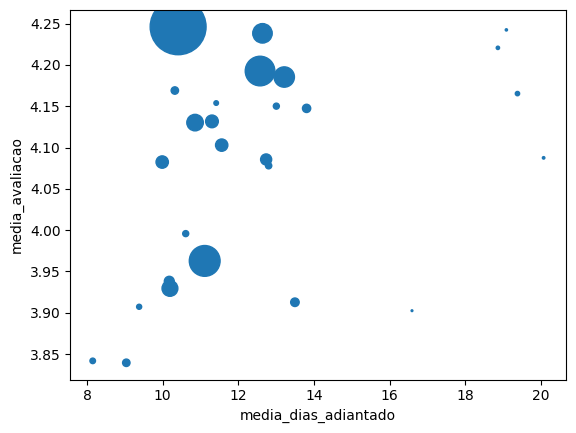

In [20]:
df.plot.scatter(x='media_dias_adiantado', y='media_avaliacao', s=df['qtd_pedidos']/25)

#Análise 3

Nesta análise a hipótese foi a de que não é o tempo de entrega que afeta a satisfação do cliente, mas sim  a promessa de quando será entregue.

Para validar esta hipótese, classifiquei os pedidos comparando a entrega real com a data prometida.

Como resultado: 92% dos pedidos chegam adiantados (nota 4,29). Os 8% que atrasaram tiveram nota 2,57. O atraso gerou uma queda de 40,1% nas notas.

In [21]:
sql("""
WITH reviews_unicas AS (
    SELECT order_id, AVG(review_score) AS nota
    FROM reviews
    GROUP BY order_id
       ),
pedidos AS (
     SELECT c.customer_state,
            julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) AS dias_entregue,
            r.nota
     FROM orders o
     JOIN customers c ON o.customer_id = c.customer_id
     JOIN reviews_unicas r ON o.order_id = r.order_id
     WHERE o.order_delivered_customer_date IS NOT NULL
)
SELECT customer_state,
       AVG(dias_entregue) AS media_dias,
       RANK() OVER (ORDER BY AVG(dias_entregue) DESC) AS ranking,
       AVG(nota) AS media_avaliacao,
       COUNT (*) AS qtd_pedidos
FROM pedidos
GROUP BY customer_state
ORDER BY ranking, media_avaliacao DESC
""")

,customer_state,media_dias,ranking,media_avaliacao,qtd_pedidos
0,RR,29.387546,1,3.902439,41
1,AP,27.121586,2,4.242424,66
2,AM,26.352644,3,4.243056,144
3,AL,24.457127,4,3.852792,394
4,PA,23.641464,5,3.909968,933
5,MA,21.441588,6,3.833567,712
6,SE,21.438862,7,3.907186,334
7,CE,21.205486,8,3.941870,1273
8,AC,21.035713,9,4.087500,80
9,PB,20.246941,10,4.076172,512


In [22]:
sql("""
WITH reviews_unicas AS (
    SELECT order_id, AVG(review_score) AS nota
    FROM reviews
    GROUP BY order_id
       ),
entregas AS (
    SELECT r.nota,
           julianday(o.order_estimated_delivery_date) - julianday(o.order_delivered_customer_date) AS dias_adiantado
    FROM orders o
    JOIN reviews_unicas r ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
)
SELECT
       CASE
           WHEN dias_adiantado > 0 THEN 'Adiantado'
           WHEN dias_adiantado < 0 THEN 'Atrasado'
           ELSE 'No prazo'
       END AS status_entrega,
       COUNT (*) AS qtd_pedidos,
       COUNT (*)*100.0/SUM(COUNT(*)) OVER() AS percentual,
       AVG(nota) AS media_avaliacao
FROM entregas
GROUP BY status_entrega

""")

,status_entrega,qtd_pedidos,percentual,media_avaliacao
0,Adiantado,88168,92.004591,4.294151
1,Atrasado,7662,7.995409,2.566562


In [23]:
sql("""
WITH reviews_unicas AS (
    SELECT order_id, AVG(review_score) AS nota
    FROM reviews
    GROUP BY order_id
       ),
entregas AS (
    SELECT r.nota,
           julianday(o.order_estimated_delivery_date) - julianday(o.order_delivered_customer_date) AS dias_adiantado
    FROM orders o
    JOIN reviews_unicas r ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
)
SELECT
       CASE
           WHEN dias_adiantado > 0 THEN 'Adiantado'
           WHEN dias_adiantado < 0 THEN 'Atrasado'
           ELSE 'No prazo'
       END AS status_entrega,
       COUNT (*) AS qtd_pedidos,
       COUNT (*)*100.0/SUM(COUNT(*)) OVER() AS percentual,
       AVG(nota) AS media_avaliacao
FROM entregas
GROUP BY status_entrega

""")

,status_entrega,qtd_pedidos,percentual,media_avaliacao
0,Adiantado,88168,92.004591,4.294151
1,Atrasado,7662,7.995409,2.566562


In [24]:
sql("""
WITH reviews_unicas AS (
    SELECT order_id, AVG(review_score) AS nota
    FROM reviews
    GROUP BY order_id
       ),
entregas AS (
    SELECT r.nota,
           julianday(o.order_estimated_delivery_date) - julianday(o.order_delivered_customer_date) AS dias_adiantado
    FROM orders o
    JOIN reviews_unicas r ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
)
SELECT
       CASE
           WHEN dias_adiantado > 0 THEN 'Adiantado'
           WHEN dias_adiantado < 0 THEN 'Atrasado'
           ELSE 'No prazo'
       END AS status_entrega,
       COUNT (*) AS qtd_pedidos,
       COUNT (*)*100.0/SUM(COUNT(*)) OVER() AS percentual,
       AVG(nota) AS media_avaliacao
FROM entregas
GROUP BY status_entrega

""")

,status_entrega,qtd_pedidos,percentual,media_avaliacao
0,Adiantado,88168,92.004591,4.294151
1,Atrasado,7662,7.995409,2.566562


#Conclusão


A tese encontrada foi a de que a satisfação dos clientes é muito mais influenciada pela expectativa da entrega do que pela velocidade, por isso AP (27 dias, adianta 19,09) tem nota superior a AL (24 dias, adianta 8,15).

A recomendação é clara : o ideal não é entregar mais rápido, mas ajustar a promessa e cumprir os prazos.

Como limitação, vale notar que corelação não implica causalidade: outros fatores também pesam na nota.